In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df_eda = pd.read_csv("NORS_cleaned.csv")

In [23]:
df_eda

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,...,Info On Deaths,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type,Etiology_clean,Etiology_top,Setting_group
0,1971,2,California,Water,Copper,NaN,Confirmed,Restaurant,2,NaN,...,NaN,NaN,NaN,NaN,Drinking water,Community,NaN,Copper,Other,Restaurant
1,1971,6,Alabama,Water,Selenium,NaN,Confirmed,Unknown,3,NaN,...,NaN,NaN,NaN,NaN,Drinking water,Individual/Private,NaN,Selenium,Other,Unknown
2,1971,6,Arkansas,Water,Hepatitis A,NaN,Confirmed,Store,98,NaN,...,NaN,NaN,NaN,NaN,Drinking water,Other,NaN,Hepatitis A,Other,Other
3,1971,7,Mississippi,Water,Shigella sonnei,NaN,Confirmed,Camp/cabin,187,NaN,...,NaN,NaN,NaN,NaN,Drinking water,Community,NaN,Shigella,Shigella,Other
4,1971,7,New Jersey,Water,Hepatitis A,NaN,Confirmed,Camp/cabin,22,NaN,...,NaN,NaN,NaN,NaN,Drinking water,Other,NaN,Hepatitis A,Other,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24757,2023,12,Multistate,Environmental,"Escherichia coli, Shiga toxin-producing",O157:H7,Confirmed,NaN,5,3.0,...,5.0,NaN,NaN,NaN,NaN,NaN,NaN,STEC,STEC,Unknown
24758,2023,12,Illinois,Person-to-person,Norovirus unknown,NaN,Confirmed,Long-term care/nursing home/assisted living fa...,36,1.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,Norovirus,Norovirus,Long-term care
24759,2023,12,South Dakota,Indeterminate/unknown,Salmonella enterica,Litchfield,Confirmed,Long-term care/nursing home/assisted living fa...,3,1.0,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,Salmonella,Salmonella,Long-term care
24760,2023,12,Arizona,Food,Salmonella enterica,Javiana,Confirmed,NaN,3,1.0,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,Salmonella,Salmonella,Unknown


# Introduction

In [24]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 24762 entries, 0 to 24761
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          24762 non-null  int64  
 1   Month                         24762 non-null  int64  
 2   State                         24762 non-null  str    
 3   Primary Mode                  24762 non-null  str    
 4   Etiology                      24762 non-null  str    
 5   Serotype or Genotype          13002 non-null  str    
 6   Etiology Status               24762 non-null  str    
 7   Setting                       23019 non-null  str    
 8   Illnesses                     24762 non-null  int64  
 9   Hospitalizations              22706 non-null  float64
 10  Info On Hospitalizations      22507 non-null  float64
 11  Deaths                        22997 non-null  float64
 12  Info On Deaths                22503 non-null  float64
 13  Food Vehicle

In [25]:
df_eda["Year"].value_counts().sort_index()

Year
1971      11
1972      17
1973      14
1974      14
1975       9
1976      10
1977      18
1978      25
1979      26
1980      34
1981      27
1982      53
1983      41
1984      25
1985      15
1986      16
1987      19
1988      17
1989      17
1990      14
1991      15
1992      26
1993      25
1994      18
1995      32
1996      16
1997      14
1998     393
1999     384
2000     488
2001     480
2002     513
2003     423
2004     565
2005     433
2006     645
2007     588
2008     528
2009     990
2010    1313
2011    1285
2012    1582
2013    1633
2014    1626
2015    1656
2016    1547
2017    1354
2018    1404
2019    1320
2020     551
2021     608
2022     828
2023    1057
Name: count, dtype: int64

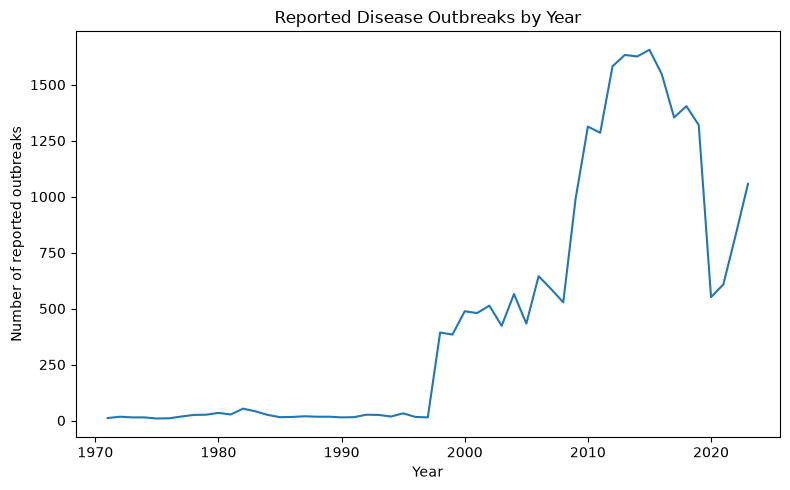

In [26]:
yearly_outbreaks = df_eda["Year"].value_counts().sort_index()
yearly_outbreaks.plot(kind="line", figsize=(8, 5))

plt.xlabel("Year")
plt.ylabel("Number of reported outbreaks")
plt.title("Reported Disease Outbreaks by Year")
plt.tight_layout()
plt.show()

# Objective 1

In [27]:
df_eda['Etiology_top'].value_counts()

Etiology_top
Norovirus                 13031
Salmonella                 3855
Other                      2123
Shigella                   1171
STEC                       1127
Legionella pneumophila      726
Campylobacter               688
Clostridium                 648
Cryptosporidium             629
Scombroid toxin             423
Ciguatoxin                  341
Name: count, dtype: int64

In [28]:
df_eda['Etiology_top'].value_counts(normalize=True) * 100

Etiology_top
Norovirus                 52.624990
Salmonella                15.568209
Other                      8.573621
Shigella                   4.729020
STEC                       4.551329
Legionella pneumophila     2.931912
Campylobacter              2.778451
Clostridium                2.616913
Cryptosporidium            2.540183
Scombroid toxin            1.708263
Ciguatoxin                 1.377110
Name: proportion, dtype: float64

In [29]:
etiology_summary = (df_eda['Etiology_top'].value_counts().rename_axis('Etiology').reset_index(name='Outbreaks'))
etiology_summary['Percentage'] = (etiology_summary['Outbreaks']/ etiology_summary['Outbreaks'].sum() * 100)
etiology_summary

,Etiology,Outbreaks,Percentage
0,Norovirus,13031,52.624990
1,Salmonella,3855,15.568209
2,Other,2123,8.573621
3,Shigella,1171,4.729020
4,STEC,1127,4.551329
5,Legionella pneumophila,726,2.931912
6,Campylobacter,688,2.778451
7,Clostridium,648,2.616913
8,Cryptosporidium,629,2.540183
9,Scombroid toxin,423,1.708263


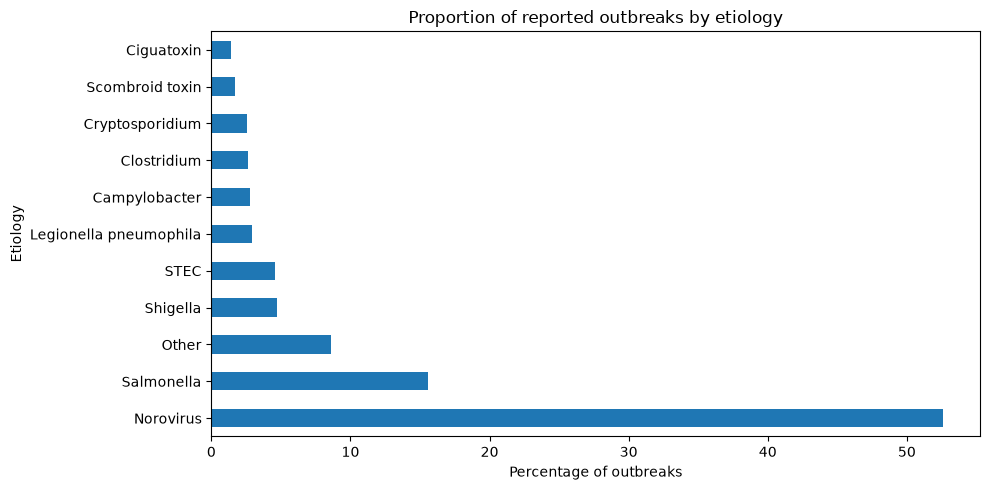

In [30]:
etiology_summary.plot(kind='barh',
    x='Etiology',
    y='Percentage',
    figsize=(10, 5),
    legend=False)

plt.xlabel('Percentage of outbreaks')
plt.ylabel('Etiology')
plt.title('Proportion of reported outbreaks by etiology')
plt.tight_layout()
plt.show()

# Objective 2

In [31]:
df_eda.groupby(['Year', 'Etiology_top']).size()

Year  Etiology_top   
1971  Other                8
      Shigella             3
1972  Other               12
      Salmonella           2
      Shigella             3
                        ... 
2023  Other               76
      STEC                64
      Salmonella         149
      Scombroid toxin      9
      Shigella            20
Length: 409, dtype: int64

In [32]:
etiology_year = (df_eda.groupby(['Year', 'Etiology_top']).size().unstack(fill_value=0))
etiology_year

Etiology_top,Campylobacter,Ciguatoxin,Clostridium,Cryptosporidium,Legionella pneumophila,Norovirus,Other,STEC,Salmonella,Scombroid toxin,Shigella
Year,,,,,,,,,,,
1971,0,0,0,0,0,0,8,0,0,0,3
1972,0,0,0,0,0,0,12,0,2,0,3
1973,0,0,0,0,2,0,6,0,2,0,4
1974,0,0,0,0,1,0,8,0,2,0,3
1975,0,0,0,0,0,0,7,1,0,0,1
1976,0,0,0,0,1,0,5,0,2,0,2
1977,0,0,0,0,0,0,16,0,1,0,1
1978,1,0,0,0,4,3,11,0,2,0,4
1979,0,0,0,0,4,3,16,0,1,0,2


In [33]:
etiology_year_pct = etiology_year.div(etiology_year.sum(axis=1),axis=0) * 100
etiology_year_pct

Etiology_top,Campylobacter,Ciguatoxin,Clostridium,Cryptosporidium,Legionella pneumophila,Norovirus,Other,STEC,Salmonella,Scombroid toxin,Shigella
Year,,,,,,,,,,,
1971,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.727273,0.000000,0.000000,0.000000,27.272727
1972,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.588235,0.000000,11.764706,0.000000,17.647059
1973,0.000000,0.000000,0.000000,0.000000,14.285714,0.000000,42.857143,0.000000,14.285714,0.000000,28.571429
1974,0.000000,0.000000,0.000000,0.000000,7.142857,0.000000,57.142857,0.000000,14.285714,0.000000,21.428571
1975,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,77.777778,11.111111,0.000000,0.000000,11.111111
1976,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,50.000000,0.000000,20.000000,0.000000,20.000000
1977,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,88.888889,0.000000,5.555556,0.000000,5.555556
1978,4.000000,0.000000,0.000000,0.000000,16.000000,12.000000,44.000000,0.000000,8.000000,0.000000,16.000000
1979,0.000000,0.000000,0.000000,0.000000,15.384615,11.538462,61.538462,0.000000,3.846154,0.000000,7.692308


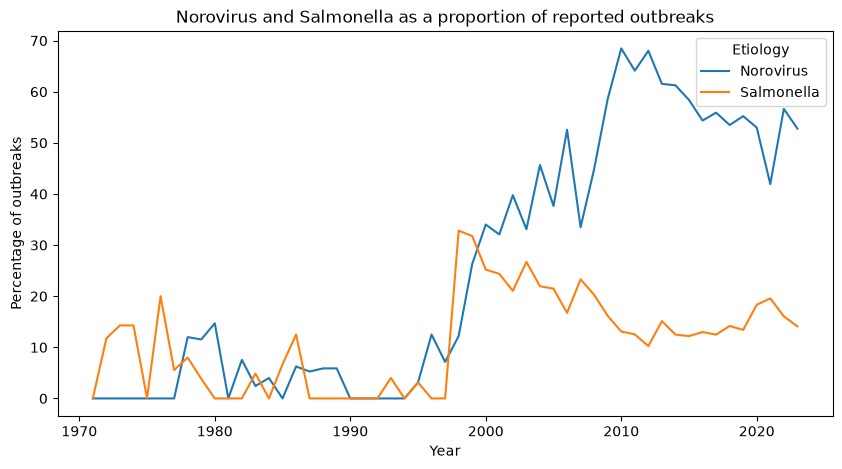

In [34]:
etiology_year_pct[['Norovirus', 'Salmonella']].plot(
    kind='line',
    figsize=(10, 5))

plt.ylabel('Percentage of outbreaks')
plt.xlabel('Year')
plt.title('Norovirus and Salmonella as a proportion of reported outbreaks')
plt.legend(title='Etiology')
plt.show()

In [36]:
def get_decade(year):
    decade = (year // 10) * 10
    return str(decade) + "s"
df_eda['Decade'] = df_eda['Year'].apply(get_decade)

df_eda.groupby('Decade').size()

Decade
1970s      144
1980s      264
1990s      937
2000s     5653
2010s    14720
2020s     3044
dtype: int64

In [37]:
etiology_decade = (
    df_eda.groupby(['Decade', 'Etiology_top'])
    .size()
    .unstack(fill_value=0)
)

In [38]:
etiology_decade_pct = etiology_decade.div(
    etiology_decade.sum(axis=1),
    axis=0
) * 100

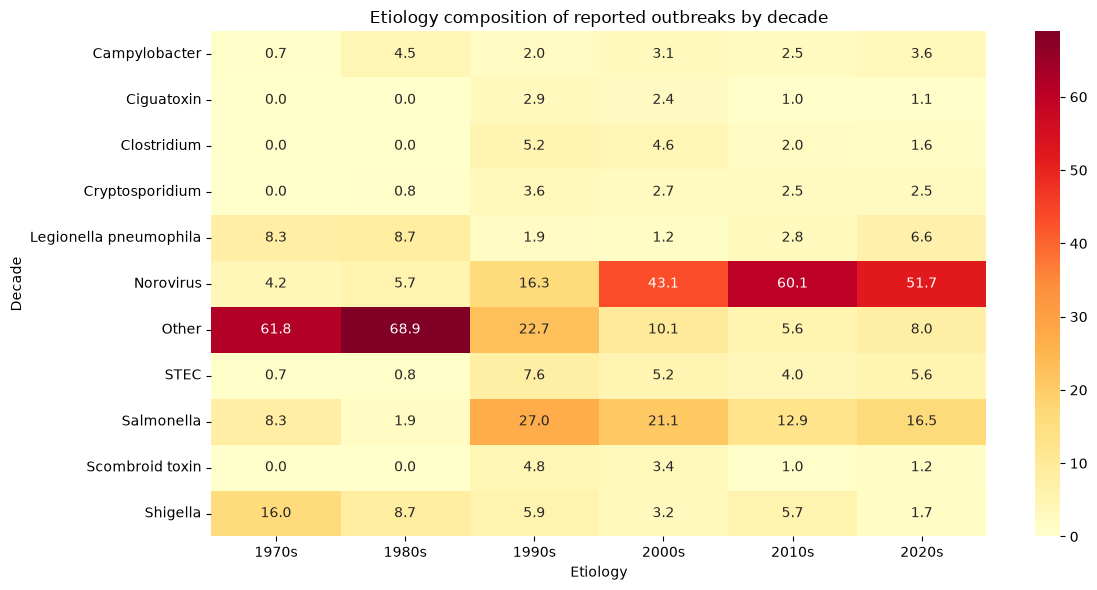

In [39]:
plt.figure(figsize=(12, 6))

sns.heatmap(etiology_decade_pct.T,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd')

plt.xlabel('Etiology')
plt.ylabel('Decade')
plt.title('Etiology composition of reported outbreaks by decade')

plt.tight_layout()
plt.show()

In [40]:
df_eda['Month'].value_counts().sort_index()

Month
1     2995
2     2752
3     2769
4     2231
5     1841
6     1882
7     1905
8     1752
9     1382
10    1351
11    1595
12    2307
Name: count, dtype: int64

In [41]:
etiology_month = (
    df_eda.groupby(['Month', 'Etiology_top'])
    .size()
    .unstack(fill_value=0)
)

In [42]:
etiology_month_pct = etiology_month.div(
    etiology_month.sum(axis=1),
    axis=0
) * 100

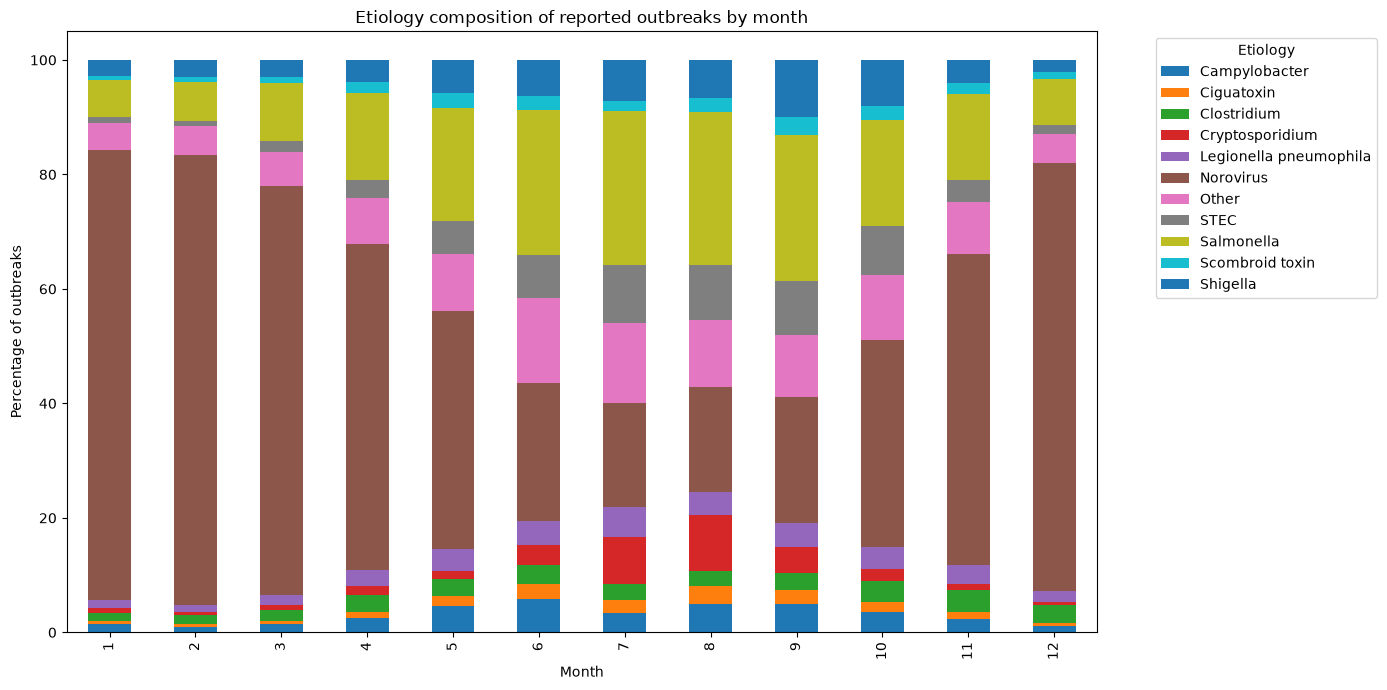

In [ ]:
etiology_month_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.ylabel('Percentage of outbreaks')
plt.xlabel('Month')
plt.title('Etiology composition of reported outbreaks by month')
plt.legend(
    title='Etiology',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

# Objective 3

In [44]:
df_eda['Primary Mode'].value_counts()

Primary Mode
Food                     10369
Person-to-person          9809
Water                     2051
Indeterminate/unknown     1938
Animal contact             509
Environmental               86
Name: count, dtype: int64

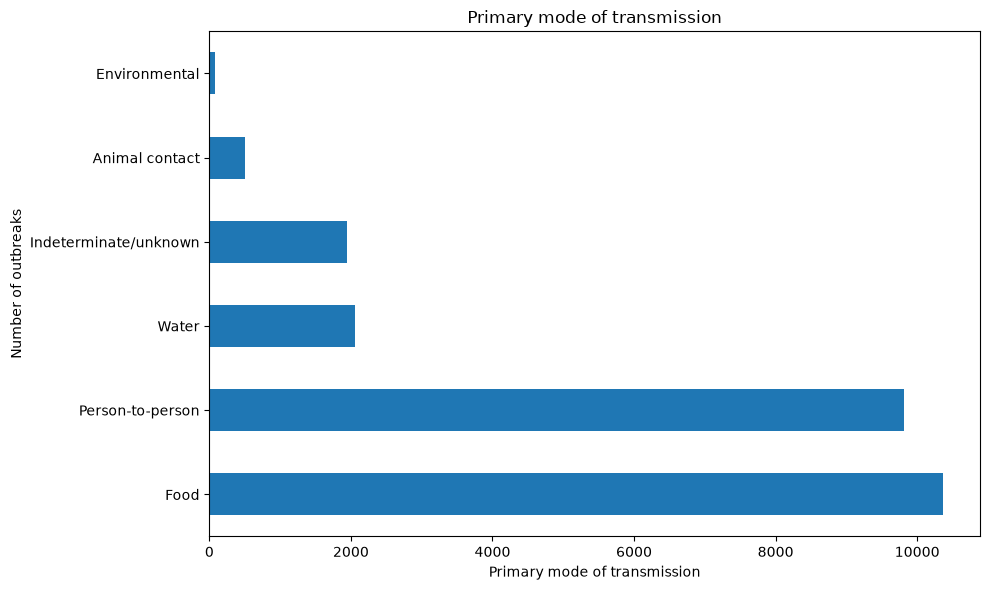

In [76]:
df_eda['Primary Mode'].value_counts().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Primary mode of transmission')
plt.ylabel('Number of outbreaks')
plt.title('Primary mode of transmission')
plt.tight_layout()
plt.show()

In [45]:
etiology_mode = (
    df_eda.groupby(['Etiology_top', 'Primary Mode'])
    .size()
    .unstack(fill_value=0)
)


In [46]:
etiology_mode_pct = etiology_mode.div(
    etiology_mode.sum(axis=1),
    axis=0
) * 100

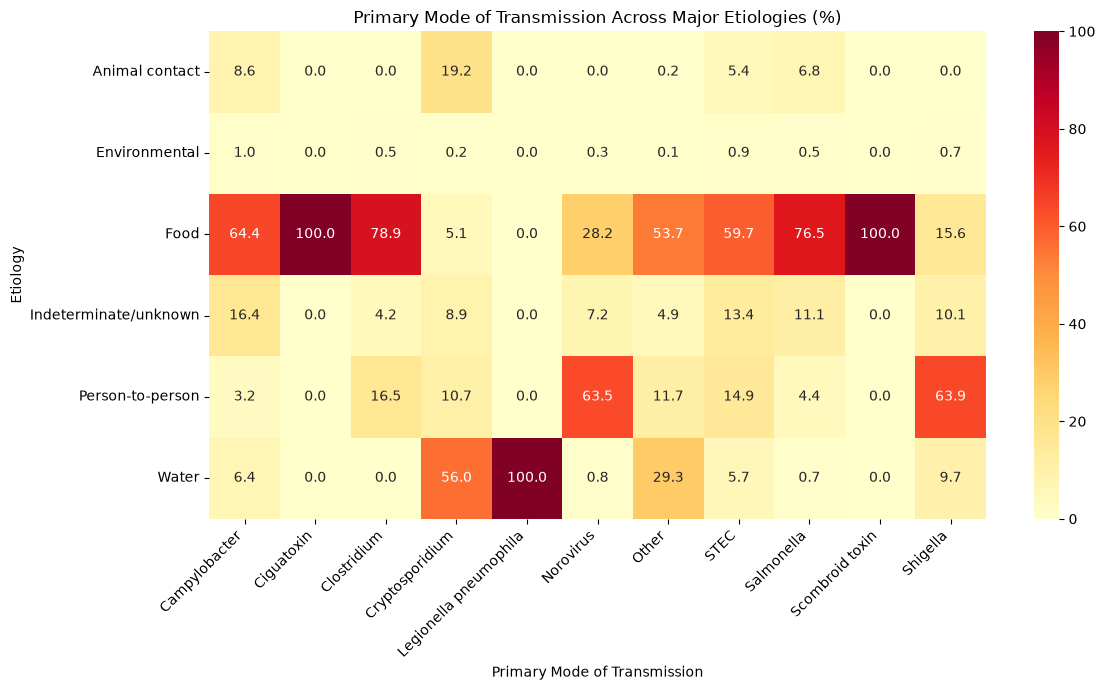

In [47]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    etiology_mode_pct.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.xlabel("Primary Mode of Transmission")
plt.ylabel("Etiology")
plt.title("Primary Mode of Transmission Across Major Etiologies (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Objective 4

In [48]:
df_eda['Setting'].value_counts()

Setting
Long-term care/nursing home/assisted living facility                                  7134
Restaurant: Other                                                                     2421
Private home/residence                                                                1967
Restaurant: Sit-down dining                                                           1720
Other                                                                                 1167
                                                                                      ... 
Petting zoo;Fairground                                                                   1
Fairground;Petting zoo                                                                   1
Office/indoor workplace;Restaurant: Fast-food (drive up service or pay at counter)       1
Park/outdoor area;Event space                                                            1
Grocery store/bakery/deli/convenience store;Residence - Single-family home        

In [49]:
etiology_setting = (
    df_eda.groupby(['Etiology_top','Setting_group'])
    .size()
    .unstack(fill_value=0)
)

In [50]:
etiology_setting_pct = etiology_setting.div(
    etiology_setting.sum(axis=1),
    axis=0
) * 100

In [51]:
etiology_setting_pct

Setting_group,Community,Grocery,Hospital,Hotel,Long-term care,Other,Private residence,Restaurant,School,Unknown
Etiology_top,,,,,,,,,,
Campylobacter,1.889535,0.145349,0.290698,0.145349,1.162791,38.226744,17.732558,24.563953,2.906977,12.936047
Ciguatoxin,0.000000,0.879765,0.000000,0.000000,0.000000,8.504399,73.900293,12.316716,0.000000,4.398827
Clostridium,1.543210,0.771605,3.858025,0.000000,11.728395,17.746914,14.660494,39.043210,1.697531,8.950617
Cryptosporidium,15.262321,0.158983,0.317965,5.246423,0.476948,52.782194,8.108108,0.476948,11.605723,5.564388
Legionella pneumophila,4.407713,0.137741,21.487603,24.517906,13.911846,29.476584,1.377410,0.550964,0.137741,3.994490
Norovirus,0.391374,0.322308,3.192387,0.422070,51.147264,8.625585,1.765022,21.387461,5.471568,7.274960
Other,6.547339,1.036269,2.166745,5.746585,8.337259,21.573245,12.058408,27.319830,5.463966,9.750353
STEC,1.153505,1.242236,0.443656,0.000000,0.798580,29.991127,15.794144,21.561668,14.640639,14.374445
Salmonella,1.219196,1.582361,0.492866,0.077821,2.334630,21.348898,16.887160,35.071336,4.280156,16.705577


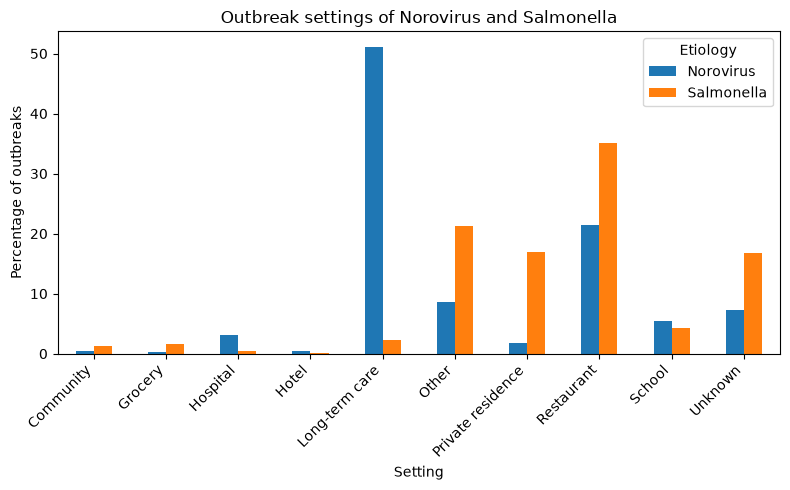

In [ ]:
norovirus_salmonella_setting = (
    etiology_setting_pct.loc[['Norovirus', 'Salmonella']]
    .T
)

norovirus_salmonella_setting.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.ylabel('Percentage of outbreaks')
plt.xlabel('Setting')
plt.title('Outbreak settings of Norovirus and Salmonella')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Etiology')
plt.tight_layout()
plt.show()

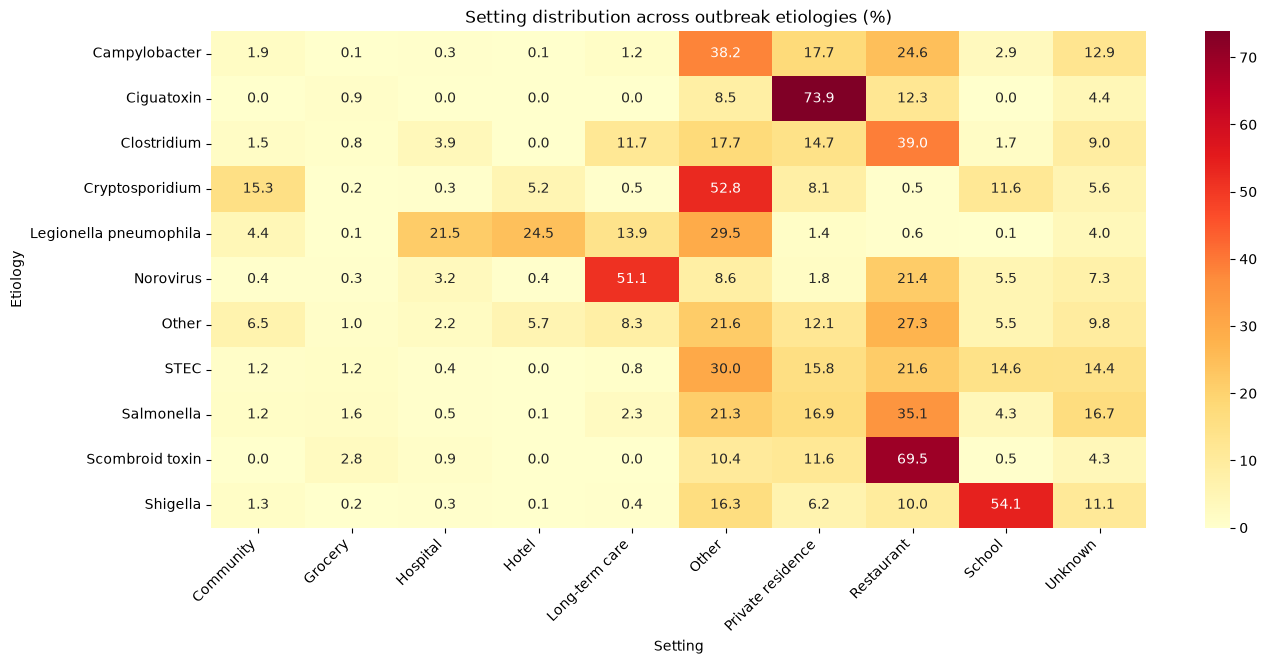

In [ ]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    etiology_setting_pct,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.xlabel('Setting')
plt.ylabel('Etiology')
plt.title('Setting distribution across outbreak etiologies (%)')
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()

# Objective 5

In [54]:
df_eda['Illnesses'].describe()

count     24762.000000
mean         48.738672
std        2564.157714
min           2.000000
25%           6.000000
50%          16.000000
75%          35.000000
max      403000.000000
Name: Illnesses, dtype: float64

In [55]:
df_eda[df_eda['Illnesses'] < 400000]['Illnesses'].describe()

count    24761.000000
mean        32.465046
std        131.005305
min          2.000000
25%          6.000000
50%         16.000000
75%         35.000000
max      13000.000000
Name: Illnesses, dtype: float64

In [56]:
df_eda[df_eda["Hospitalizations"] > df_eda["Illnesses"]]

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,...,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type,Etiology_clean,Etiology_top,Setting_group,Decade
2294,2001,12,California,Food,Shigella sonnei,NaN,Confirmed,Restaurant: Other,7,8.0,...,"green salad;carrots, unspecified;caesar salad",NaN,Multiple,NaN,NaN,NaN,Shigella,Shigella,Restaurant,2000s


In [57]:
df_eda[df_eda["Info On Hospitalizations"] > df_eda["Illnesses"]]

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,...,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type,Etiology_clean,Etiology_top,Setting_group,Decade
568,1998,1,California,Food,Scombroid toxin,NaN,Confirmed,Restaurant: Other,4,0.0,...,"fish, ahi",NaN,Fish,NaN,NaN,NaN,Scombroid toxin,Scombroid toxin,Restaurant,1990s
576,1998,1,Maryland,Food,Salmonella enterica,Enteritidis,Confirmed,Restaurant: Other,8,0.0,...,"eggs, other;cake, tiramisu",NaN,Multiple,NaN,NaN,NaN,Salmonella,Salmonella,Restaurant,1990s
577,1998,1,Massachusetts,Food,Shigella sonnei,NaN,Confirmed,Restaurant: Other,79,6.0,...,"dips, unspecified",NaN,Multiple,NaN,NaN,NaN,Shigella,Shigella,Restaurant,1990s
578,1998,1,Minnesota,Food,Shigella sonnei,NaN,Confirmed,Other,19,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Shigella,Shigella,Other,1990s
581,1998,1,Pennsylvania,Food,Salmonella enterica,Enteritidis,Confirmed,Restaurant: Other;Caterer,4,2.0,...,"meatballs;pasta, unspecified",NaN,Multiple,NaN,NaN,NaN,Salmonella,Salmonella,Restaurant,1990s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3437,2004,5,Illinois,Food,Salmonella enterica,Anatum,Confirmed,Restaurant: Other,3,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Salmonella,Salmonella,Restaurant,2000s
4699,2006,9,Iowa,Food,Salmonella enterica,"I 4,[5],12:i:-",Confirmed,Other;Private home/residence,4,3.0,...,potato salad;pasta salad,NaN,Multiple,NaN,NaN,NaN,Salmonella,Salmonella,Other,2000s
4898,2007,1,Colorado,Food,Norovirus unknown,NaN,Confirmed,Banquet Facility (food prepared and served on-...,19,0.0,...,caramel rolls;honeydew melon,NaN,Multiple,NaN,NaN,NaN,Norovirus,Norovirus,Other,2000s
5151,2007,6,Ohio,Food,Salmonella enterica,Heidelberg,Confirmed,Restaurant: Other,24,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Salmonella,Salmonella,Restaurant,2000s


In [58]:
df_eda[(df_eda["Hospitalizations"] > 0) & (df_eda["Info On Hospitalizations"].isna())]

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,...,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type,Etiology_clean,Etiology_top,Setting_group,Decade
36,1973,7,Virginia,Water,Legionella pneumophila,unknown,Confirmed,Factory/industrial facility,10,9.0,...,NaN,NaN,NaN,Other/Environmental water,NaN,NaN,Legionella pneumophila,Legionella pneumophila,Other,1970s
71,1976,7,Pennsylvania,Water,Legionella unknown,NaN,Confirmed,Hotel/motel,182,145.0,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Hotel,1970s
74,1976,11,Connecticut,Water,Legionella pneumophila,serogroup 1,Confirmed,Community/municipality,28,19.0,...,NaN,NaN,NaN,Other/Environmental water,NaN,NaN,Legionella pneumophila,Legionella pneumophila,Community,1970s
80,1977,5,Indiana,Water,Legionella unknown,NaN,Confirmed,Hotel/motel,39,35.0,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Hotel,1970s
81,1977,5,Vermont,Water,Legionella unknown,NaN,Confirmed,Community/municipality,69,56.0,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Community,1970s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21574,2019,11,Delaware,Person-to-person,Norovirus unknown,NaN,Confirmed,Long-term care/nursing home/assisted living fa...,22,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Norovirus,Norovirus,Long-term care,2010s
23920,2023,2,Washington,Person-to-person,Norovirus,NaN,Confirmed,Long-term care/nursing home/assisted living fa...,50,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Norovirus,Norovirus,Long-term care,2020s
24080,2023,3,Washington,Person-to-person,Norovirus,NaN,Confirmed,Long-term care/nursing home/assisted living fa...,26,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Norovirus,Norovirus,Long-term care,2020s
24206,2023,4,Washington,Person-to-person,Norovirus,NaN,Confirmed,Long-term care/nursing home/assisted living fa...,2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Norovirus,Norovirus,Long-term care,2020s


In [59]:
df_eda[(df_eda["Deaths"] > 0) & (df_eda["Info On Deaths"].isna())]

,Year,Month,State,Primary Mode,Etiology,Serotype or Genotype,Etiology Status,Setting,Illnesses,Hospitalizations,...,Food Vehicle,Food Contaminated Ingredient,IFSAC Category,Water Exposure,Water Type,Animal Type,Etiology_clean,Etiology_top,Setting_group,Decade
40,1973,12,Maryland,Water,Shigella unknown,NaN,Confirmed,Hospital,94,NaN,...,NaN,NaN,NaN,Drinking water,Other,NaN,Shigella,Shigella,Hospital,1970s
60,1975,8,Kansas,Water,Legionella unknown,NaN,Confirmed,Hospital,3,NaN,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Hospital,1970s
71,1976,7,Pennsylvania,Water,Legionella unknown,NaN,Confirmed,Hotel/motel,182,145.0,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Hotel,1970s
74,1976,11,Connecticut,Water,Legionella pneumophila,serogroup 1,Confirmed,Community/municipality,28,19.0,...,NaN,NaN,NaN,Other/Environmental water,NaN,NaN,Legionella pneumophila,Legionella pneumophila,Community,1970s
79,1977,5,California,Water,Legionella unknown,NaN,Confirmed,Hospital,49,NaN,...,NaN,NaN,NaN,Undetermined water,NaN,NaN,Legionella unknown,Other,Hospital,1970s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5797,2008,7,New York,Water,Legionella pneumophila,serogroup 1,Confirmed,Assisted Living/Rehab,13,13.0,...,NaN,NaN,NaN,Drinking water,Community,NaN,Legionella pneumophila,Legionella pneumophila,Other,2000s
5888,2008,9,New York,Water,Legionella pneumophila,serogroup 1,Confirmed,Assisted Living/Rehab,3,NaN,...,NaN,NaN,NaN,Drinking water,Community,NaN,Legionella pneumophila,Legionella pneumophila,Other,2000s
6329,2009,2,Multistate,Food,Salmonella enterica,Carrau,Confirmed,Grocery store/bakery/deli/convenience store,53,4.0,...,melon,NaN,Fruits,NaN,NaN,NaN,Salmonella,Salmonella,Grocery,2000s
6804,2009,8,Multistate,Food,"Escherichia coli, Shiga toxin-producing",O157:H7,Confirmed,Other,32,19.0,...,"ground beef, other",NaN,Beef,NaN,NaN,NaN,STEC,STEC,Other,2000s


In [60]:
df_eda.groupby('Etiology_top')['Illnesses'].describe()

,count,mean,std,min,25%,50%,75%,max
Etiology_top,,,,,,,,
Campylobacter,688.0,23.125000,141.627180,2.0,3.0,5.0,12.25,3000.0
Ciguatoxin,341.0,3.656891,2.526830,2.0,2.0,3.0,4.00,29.0
Clostridium,648.0,35.566358,74.441508,2.0,5.0,14.0,35.00,950.0
Cryptosporidium,629.0,710.496025,16076.788594,2.0,4.0,7.0,20.00,403000.0
Legionella pneumophila,726.0,5.606061,9.528131,2.0,2.0,3.0,4.00,107.0
Norovirus,13031.0,37.004067,67.513423,2.0,13.0,25.0,45.00,5000.0
Other,2123.0,34.780970,194.766202,2.0,4.0,9.0,23.00,5000.0
STEC,1127.0,17.243123,66.538063,2.0,3.0,6.0,14.00,1400.0
Salmonella,3855.0,26.428275,76.863907,2.0,4.0,9.0,22.00,1939.0


In [61]:
median_illnesses = df_eda.groupby('Etiology_top')['Illnesses'].median()

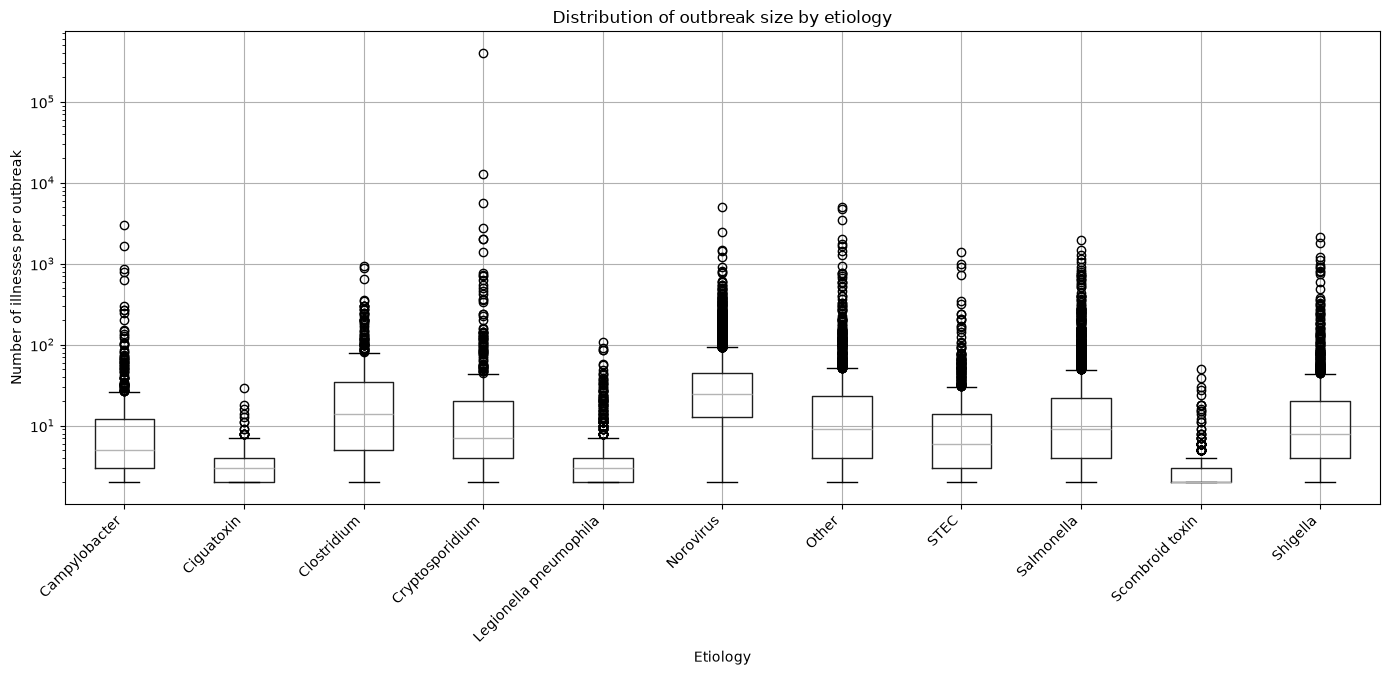

In [62]:
df_eda.boxplot(
    column='Illnesses',
    by='Etiology_top',
    figsize=(14, 7)
)

plt.yscale('log')
plt.xlabel('Etiology')
plt.ylabel('Number of illnesses per outbreak')
plt.title('Distribution of outbreak size by etiology')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

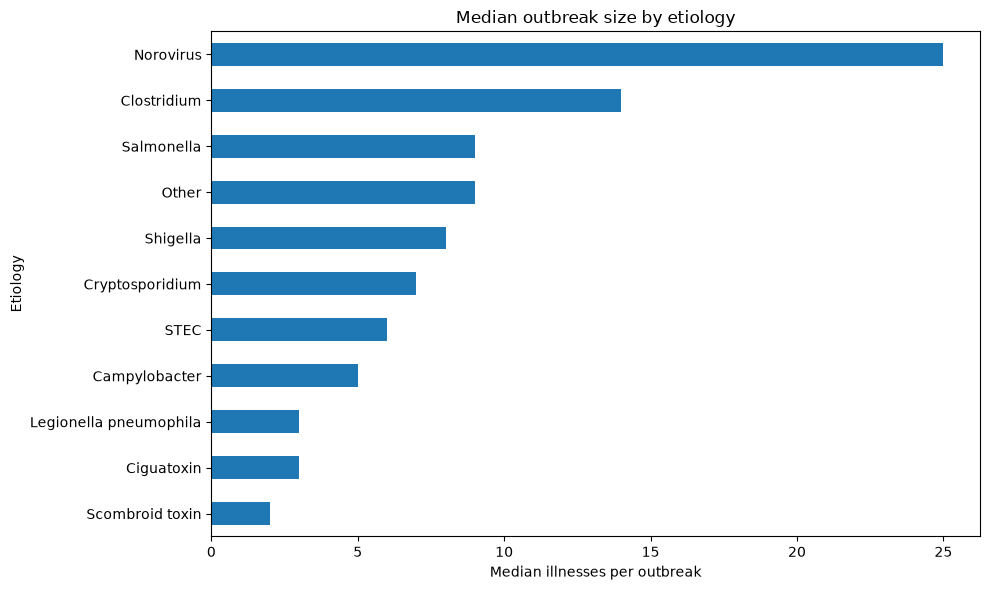

In [ ]:
median_illnesses.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Median illnesses per outbreak')
plt.ylabel('Etiology')
plt.title('Median outbreak size by etiology')
plt.tight_layout()
plt.show()

# Objective 6

In [64]:
df_eda['Info On Hospitalizations'].value_counts(dropna=False)

Info On Hospitalizations
NaN      2255
2.0      2106
0.0      1573
3.0      1442
4.0      1152
         ... 
778.0       1
179.0       1
257.0       1
182.0       1
325.0       1
Name: count, Length: 310, dtype: int64

In [65]:
df_eda[['Hospitalizations', 'Info On Hospitalizations']].sample(20)

,Hospitalizations,Info On Hospitalizations
1417,2.0,2.0
23326,0.0,4.0
4394,0.0,11.0
16580,0.0,11.0
6122,0.0,0.0
18712,0.0,3.0
20191,1.0,92.0
21794,0.0,10.0
20660,0.0,18.0
21363,0.0,34.0


In [66]:
df_eda['Hospitalizations'].describe()

count    22706.000000
mean         1.529640
std          6.063013
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        308.000000
Name: Hospitalizations, dtype: float64

In [67]:
df_eda.groupby('Etiology_top')['Hospitalizations'].median()

Etiology_top
Campylobacter             0.0
Ciguatoxin                0.0
Clostridium               0.0
Cryptosporidium           0.0
Legionella pneumophila    2.0
Norovirus                 0.0
Other                     0.0
STEC                      2.0
Salmonella                1.0
Scombroid toxin           0.0
Shigella                  0.0
Name: Hospitalizations, dtype: float64

In [68]:
df_eda['Had_hospitalization'] = df_eda['Hospitalizations'] > 0

In [69]:
hospitalization_rate = (df_eda.groupby('Etiology_top')['Had_hospitalization'].mean()* 100)
hospitalization_rate.sort_values(ascending=False)

Etiology_top
Legionella pneumophila    83.746556
STEC                      68.322981
Salmonella                65.706874
Campylobacter             37.063953
Shigella                  33.134073
Other                     32.124352
Cryptosporidium           28.775835
Norovirus                 26.644156
Clostridium               24.537037
Ciguatoxin                21.114370
Scombroid toxin            5.437352
Name: Had_hospitalization, dtype: float64

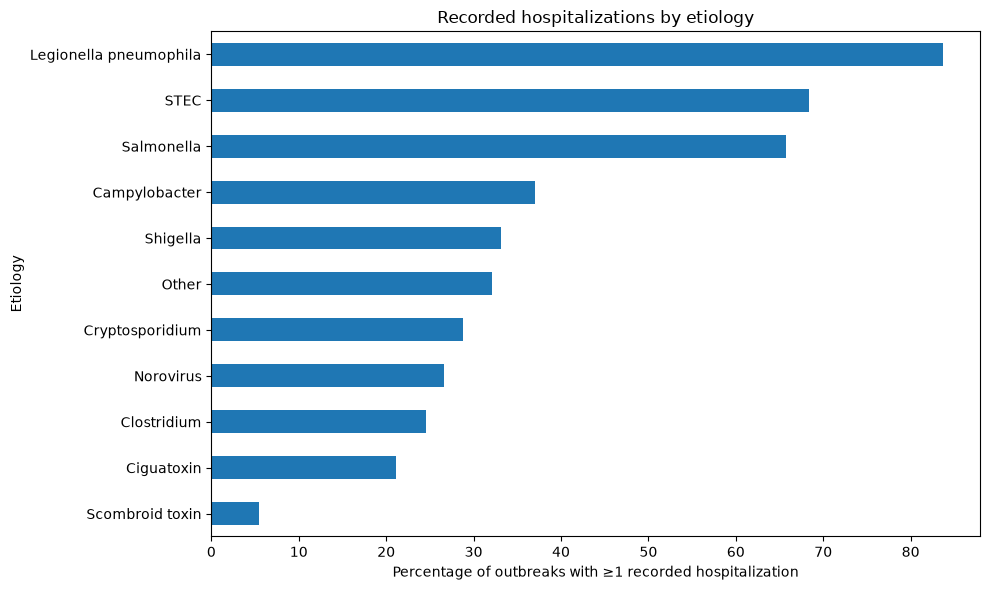

In [ ]:
hospitalization_rate.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Percentage of outbreaks with ≥1 recorded hospitalization')
plt.ylabel('Etiology')
plt.title('Recorded hospitalizations by etiology')
plt.tight_layout()
plt.show()

# Objective 7

In [71]:
df_eda['Deaths'].describe()

count    22997.000000
mean         0.074401
std          0.644150
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         50.000000
Name: Deaths, dtype: float64

In [72]:
df_eda['Had_deaths'] = df_eda['Deaths'] > 0

In [73]:
death_rate = (df_eda.groupby('Etiology_top')['Had_deaths'].mean()* 100)
death_rate.sort_values(ascending=False)

Etiology_top
Legionella pneumophila    27.685950
Other                      6.877061
Clostridium                4.783951
STEC                       4.525288
Norovirus                  3.514696
Salmonella                 2.905318
Shigella                   0.426985
Cryptosporidium            0.317965
Ciguatoxin                 0.293255
Campylobacter              0.145349
Scombroid toxin            0.000000
Name: Had_deaths, dtype: float64

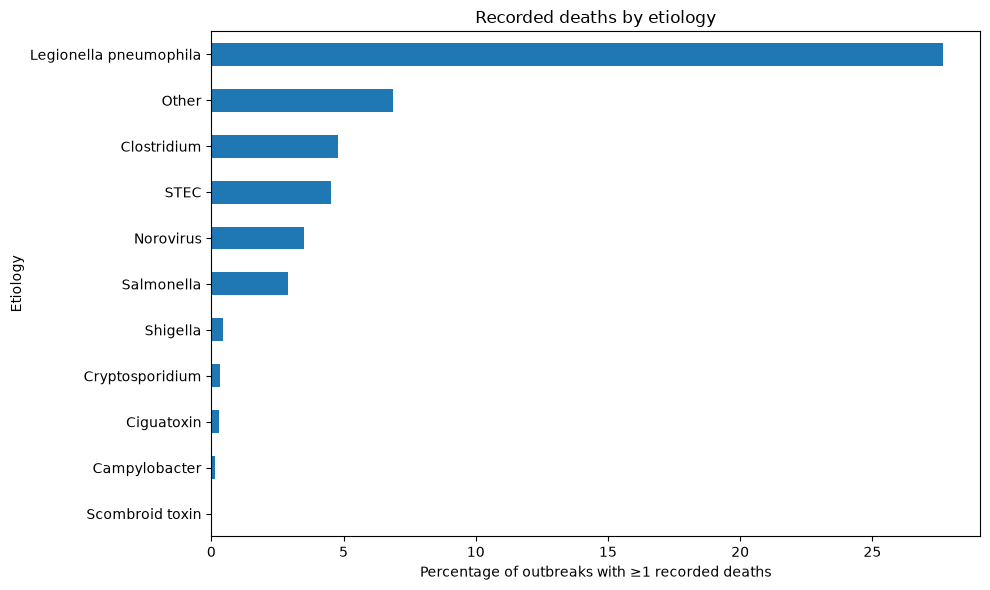

In [ ]:
death_rate.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Percentage of outbreaks with ≥1 recorded deaths')
plt.ylabel('Etiology')
plt.title('Recorded deaths by etiology')
plt.tight_layout()
plt.show()